# Resnet Bayesien

In [1]:
import torch
import torchvision
import numpy as np
from torchvision.transforms import v2
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F

from bayesian_torch.models.dnn_to_bnn import dnn_to_bnn, get_kl_loss

### Fonctions usuelles

In [2]:
def predictive_entropy(output):
    if output.ndim == 3:
        mean_output = np.mean(output, axis=0)
        return -np.sum(mean_output * np.log(mean_output + 1e-10), axis=-1)
    return -np.sum(output * np.log(output + 1e-10), axis=-1)

def mutual_information(output):
    if output.ndim == 3:
        mean_output = np.mean(output, axis=0)
        entropy = -np.sum(mean_output * np.log(mean_output + 1e-10), axis=-1)
        expected_entropy = -np.mean(np.sum(output * np.log(output + 1e-10), axis=-1), axis=0)
        return entropy - expected_entropy
    return np.zeros(output.shape[0], dtype=float)

def split_model_graph(model: nn.Module, n: int):
    """
    AI generated function.
    Splits a PyTorch model into two independently runnable models.
    Part B will contain the last N executed module calls.
    Part A will contain everything before that.
    """
    traced = torch.fx.symbolic_trace(model)
    nodes = list(traced.graph.nodes)
    
    # Find all actual module calls to determine the split point
    module_nodes = [node for node in nodes if node.op == 'call_module']
    if n >= len(module_nodes):
        raise ValueError(f"Cannot split off {n} layers; model only has {len(module_nodes)} module calls.")
        
    # The first node of Part B is the n-th module from the end
    first_node_of_b = module_nodes[-n]
    cut_idx = nodes.index(first_node_of_b)
    
    nodes_A = nodes[:cut_idx]
    nodes_B = nodes[cut_idx:]
    
    # 1. Identify "Boundary Nodes" 
    # (Tensors calculated in A that are needed in B)
    boundary_nodes = []
    for node in nodes_B:
        for in_node in node.all_input_nodes:
            if in_node in nodes_A and in_node not in boundary_nodes:
                boundary_nodes.append(in_node)
                
    # 2. Build Part A
    graph_A = torch.fx.Graph()
    env_A = {} # Maps old graph nodes to new Graph A nodes
    
    for node in nodes_A:
        env_A[node] = graph_A.node_copy(node, lambda x: env_A[x])
        
    # Set the outputs for Part A based on the boundary nodes we found
    output_args_A = tuple(env_A[node] for node in boundary_nodes)
    if len(output_args_A) == 1:
        graph_A.output(output_args_A[0])
    else:
        graph_A.output(output_args_A)
        
    model_A = torch.fx.GraphModule(traced, graph_A)
    
    # 3. Build Part B
    graph_B = torch.fx.Graph()
    env_B = {} # Maps old graph nodes to new Graph B nodes
    
    # Create input placeholders in B for the incoming tensors from A
    for node in boundary_nodes:
        env_B[node] = graph_B.placeholder(node.name)
        
    # Copy the remaining nodes into B
    for node in nodes_B:
        env_B[node] = graph_B.node_copy(node, lambda x: env_B[x])
        
    model_B = torch.fx.GraphModule(traced, graph_B)
    
    return model_A, model_B


### Hyperparamètres

In [17]:
lr = 0.005
epochs = 50
batch_size = 128
milestones = [20, 35, 45]
gamma = 0.5
num_monte_carlo = 100
nb_couches = 32

### Load Dataset

In [4]:
from medmnist import PathMNIST
from medmnist import INFO

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

info = INFO['pathmnist']

trainset = PathMNIST(split="train", download=True, size=28, transform=transform)
valset   = PathMNIST(split="val",   download=True, size=28, transform=transform)
testset  = PathMNIST(split="test",  download=True, size=28, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
valloader   = torch.utils.data.DataLoader(valset,   batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

class_names = info['label']
print(f"class names: {class_names}")

class names: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}


#### Use GPU

In [3]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')

### Créée le réseau

In [6]:
net = torchvision.models.efficientnet_b0(progress=True)
net.classifier[1] = nn.Linear(1280, 9)


const_bnn_prior_parameters = {
    "prior_mu": 0.0,
    "prior_sigma": 1.0,
    "posterior_mu_init": 0.0,
    "posterior_rho_init": -3.0,
    "type": "Reparameterization",
    "moped_enable": True,
    "moped_delta": 0.5,
}

red = torch.load("effNet.pth", map_location=device)
net.load_state_dict(red['model_state_dict'])

model_A, model_B = split_model_graph(net, n=nb_couches)
dnn_to_bnn(model_B, const_bnn_prior_parameters)


model_B.to(device)
model_A.to(device)


GraphModule(
  (features): Module(
    (0): Module(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Module(
      (0): Module(
        (block): Module(
          (0): Module(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): Module(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (scale_activation): Sigmoid()
          )
          (2): Module(
            (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1

### Training

In [9]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_B.parameters(), lr=lr)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=gamma)

In [10]:
print(device)

train_losses = []
val_losses = []

model_A.eval()
for param in model_A.parameters():
    param.requires_grad = False

for epoch in range (epochs) :
    model_B.train()
    running_loss_train = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)
        labels = labels.squeeze(1)
        optimizer.zero_grad()

        with torch.no_grad():
            features = model_A(inputs)

        output = model_B(features)
        #loss_train = criterion(output, labels)
        kl = get_kl_loss(model_B)
        ce_loss = criterion(output, labels)
        loss_train = ce_loss + kl / len(trainset)

        loss_train.backward()
        optimizer.step()

        running_loss_train += loss_train.item()
    
    train_losses.append(running_loss_train / len(trainloader))

    scheduler.step()

    # Validation
    model_B.eval()
    running_loss_val = 0.0
    with torch.no_grad():
        for i, data in enumerate(valloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)
            with torch.no_grad():
                features = model_A(inputs)
            outputs = model_B(features)
            loss_val = criterion(outputs, labels)
            running_loss_val += loss_val.item()
    
    val_losses.append(running_loss_val / len(valloader))

    print(f'[{epoch + 1}] val loss: {running_loss_val / len(valloader):.3f}')
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss_train / len(trainloader):.3f}')

print('Finished Training')

cuda


[1] val loss: 0.136
[1,    79] loss: 0.009
[2] val loss: 0.152
[2,    79] loss: 0.007
[3] val loss: 0.164
[3,    79] loss: 0.009
[4] val loss: 0.133
[4,    79] loss: 0.032
[5] val loss: 0.215
[5,    79] loss: 0.014
[6] val loss: 0.222
[6,    79] loss: 0.013
[7] val loss: 0.189
[7,    79] loss: 0.006
[8] val loss: 0.239
[8,    79] loss: 0.005
[9] val loss: 0.257
[9,    79] loss: 0.007
[10] val loss: 0.226
[10,    79] loss: 0.009
[11] val loss: 0.240
[11,    79] loss: 0.010
[12] val loss: 0.270
[12,    79] loss: 0.007
[13] val loss: 0.227
[13,    79] loss: 0.009
[14] val loss: 0.181
[14,    79] loss: 0.007
[15] val loss: 0.178
[15,    79] loss: 0.005
[16] val loss: 0.210
[16,    79] loss: 0.004
[17] val loss: 0.227
[17,    79] loss: 0.006
[18] val loss: 0.223
[18,    79] loss: 0.009
[19] val loss: 0.204
[19,    79] loss: 0.007
[20] val loss: 0.228
[20,    79] loss: 0.009
[21] val loss: 0.190
[21,    79] loss: 0.005
[22] val loss: 0.201
[22,    79] loss: 0.003
[23] val loss: 0.212
[23,   

# Save

In [11]:
torch.save({
        'model_B_state_dict': model_B.state_dict(),
        'model_A_state_dict': model_A.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses
        }, f"./{nb_couches}_{lr}_{gamma}_CoucheBayMoped.pth")

### Load

In [ ]:
red_bay = torch.load("32_0.005_0.5_CoucheBayMoped.pth", map_location=device)

model_A.load_state_dict(red_bay['model_A_state_dict'])
model_B.load_state_dict(red_bay['model_B_state_dict'])
optimizer.load_state_dict(red_bay['optimizer_state_dict'])

train_losses = red_bay['train_losses']
val_losses = red_bay['val_losses']

### Calcul accuracy

In [22]:
def evaluate(net, loader, num_monte_carlo, device):
    net.eval()
    all_preds = []
    all_labels = []
    all_outputs = []

    with torch.no_grad():
        for i, data in enumerate(loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)
            labels = labels.squeeze(1)

            output_mc = []
            for mc_run in range(num_monte_carlo):
                features = model_A(inputs)
                logits = net(features)
                probs = torch.nn.functional.softmax(logits, dim=-1)
                output_mc.append(probs)

            output = torch.stack(output_mc)
            pred_mean = output.mean(dim=0)
            y_pred = torch.argmax(pred_mean, dim=1)

            all_preds.append(y_pred.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_outputs.append(output.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_outputs = np.concatenate(all_outputs, axis=1)
    acc = (all_preds == all_labels).mean()

    return all_preds, all_labels, all_outputs, acc

all_preds, all_labels, all_outputs, test_acc = evaluate(model_B, testloader, num_monte_carlo, device)
_, _, _, train_acc = evaluate(model_B, trainloader, num_monte_carlo, device)
_, _, _, val_acc = evaluate(model_B, valloader, num_monte_carlo, device)

print(f'Train Accuracy : {100 * train_acc:.3f} %')
print(f'Val Accuracy   : {100 * val_acc:.3f} %')
print(f'Test Accuracy  : {100 * test_acc:.3f} %')

Train Accuracy : 99.657 %
Val Accuracy   : 96.521 %
Test Accuracy  : 82.033 %


### Calcul de l'adaptive uncertainty calibration error (UCE)

AUCE : 5.47%


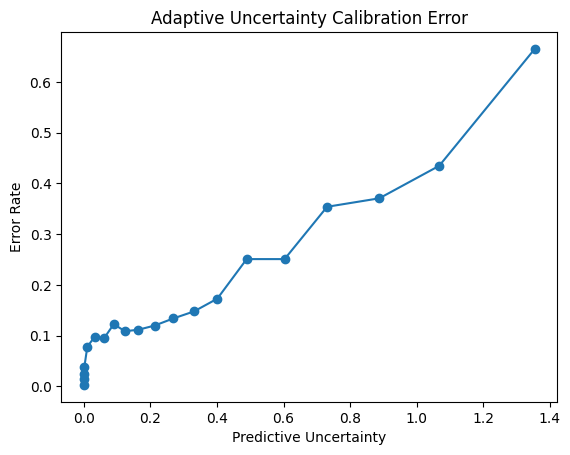

In [ ]:
predictive_uncertainty = predictive_entropy(all_outputs)
errors = (all_preds != all_labels).astype(float)
n_bins = 20
# bins adaptatifs — même nombre d'exemples par bin
bin_boundaries = np.percentile(predictive_uncertainty, np.linspace(0, 100, n_bins + 1))
bin_idx = np.digitize(predictive_uncertainty, bin_boundaries)

auce_bin_uncertainty = []  
auce_bin_error = []        
for b in range(1, n_bins + 1):
    mask = bin_idx == b
    if mask.sum() > 0:
        auce_bin_uncertainty.append(predictive_uncertainty[mask].mean())
        auce_bin_error.append(errors[mask].mean())

unc_min = predictive_uncertainty.min()
unc_max = predictive_uncertainty.max()
auce_unc_normalized = [(u - unc_min) / (unc_max - unc_min) for u in auce_bin_uncertainty]
auce_bin_sizes = [(bin_idx == b).sum() for b in range(1, n_bins + 1) if (bin_idx == b).sum() > 0]

auce = sum(
    s * abs(e - u)
    for s, e, u in zip(auce_bin_sizes, auce_bin_error, auce_unc_normalized)
) / len(all_labels)

print(f'AUCE : {100*auce:.2f}%')

plt.plot(auce_bin_uncertainty, auce_bin_error, marker='o')
plt.xlabel('Predictive Uncertainty')
plt.ylabel("Error Rate")
plt.title('Adaptive Uncertainty Calibration Error')
plt.show()


### Adaptive Certainty Error (ACE)

ACE : 6.32%


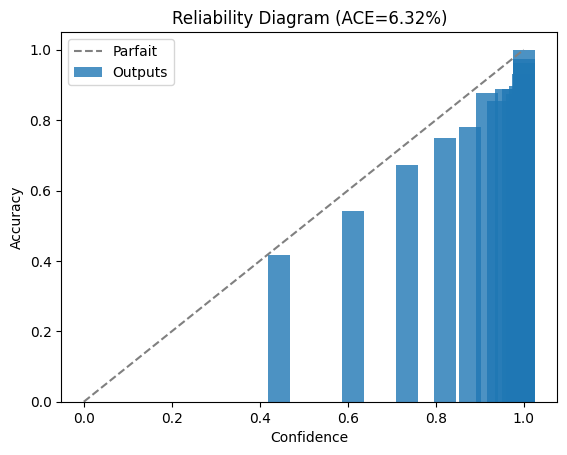

In [24]:
n_bins = 15
mean_probs = all_outputs.mean(axis=0)
sorted_idx = np.argsort(mean_probs.max(axis=-1))
confidences_sorted = mean_probs.max(axis=-1)[sorted_idx]
correct_sorted = (all_preds == all_labels).astype(float)[sorted_idx]

# Découper en bins de taille égale
bins = np.array_split(np.arange(len(all_labels)), n_bins)

ace_bins_conf = []
ace_bins_acc  = []
ace = 0

for b in bins:
    if len(b) > 0:
        conf = confidences_sorted[b].mean()
        accu  = correct_sorted[b].mean()
        ace_bins_conf.append(conf)
        ace_bins_acc.append(accu)
        ace += len(b) * abs(accu - conf)

ace /= len(all_labels)
print(f'ACE : {100*ace:.2f}%')

plt.bar(ace_bins_conf,  ace_bins_acc, width=0.05, alpha=0.8, label='Outputs')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Parfait')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.title(f'Reliability Diagram (ACE={100*ace:.2f}%)')
plt.legend()
plt.show()

### Exporte les résultats

In [ ]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.drawing.image import Image as XLImage
import os
import matplotlib.pyplot as plt
import io

def make_chart_buf(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    plt.close(fig)
    buf.seek(0)
    return buf

def save_results(
    run_type, num_monte_carlo,
    test_acc, val_acc, train_acc, ace, auce,
    auce_bin_uncertainty, auce_bin_error, auce_bin_sizes, n_bins,
    ace_bins_conf, ace_bins_acc, 
    filename="res.xlsx"
):

    header_font = Font(bold=True, color="FFFFFF", name="Arial")
    header_fill = PatternFill("solid", start_color="2F4F8F")
    normal_font = Font(name="Arial")
    center      = Alignment(horizontal="center")

    def set_header(cell, value):
        cell.value = value
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = center

    def set_col_width(ws, col, width):
        ws.column_dimensions[openpyxl.utils.get_column_letter(col)].width = width

    if os.path.exists(filename):
        wb = openpyxl.load_workbook(filename)
    else:
        wb = openpyxl.Workbook()
        wb.active.title = "Runs"

    if "Runs" not in wb.sheetnames:
        ws = wb.create_sheet("Runs", 0)
    else:
        ws = wb["Runs"]

    if ws.cell(1, 1).value is None:
        run_id = 1
    else:
        run_id = ws.max_row

    # Feuille 1 : Runs
    headers = [
        "Run ID", "Type", "num_monte_carlo",
        "train_acc (%)", "val_acc (%)", "test_acc (%)", "ACE (%)", "AUCE (%)"
    ]

    if ws.cell(1, 1).value is None:
        for col, h in enumerate(headers, start=1):
            set_header(ws.cell(1, col), h)
        for col in range(1, len(headers) + 1):
            set_col_width(ws, col, 18)

    row = ws.max_row + 1
    values = [
        run_id,
        run_type,
        num_monte_carlo,
        round(100 * train_acc, 2),
        round(100 * val_acc,   2),
        round(100 * test_acc,  2),
        round(100 * ace,       2),
        round(100 * auce,       2),
    ]
    for col, val in enumerate(values, start=1):
        ws.cell(row, col, val).font = normal_font

    # Feuille 2 : Détails du run
    ws2 = wb.create_sheet(f"Run_{run_id}")

    # EUE
    set_header(ws2.cell(1, 25), "EUE - Uncertainty")
    set_header(ws2.cell(1, 26), "EUE - Error rate")
    set_col_width(ws2, 25, 20); set_col_width(ws2, 26, 20)
    for i, (u, e) in enumerate(zip(auce_bin_uncertainty, auce_bin_error), start=2):
        ws2.cell(i, 25, round(float(u), 4)).font = normal_font
        ws2.cell(i, 26, round(float(e), 4)).font = normal_font

    # ACE
    set_header(ws2.cell(1, 28), "ACE - Confidence")
    set_header(ws2.cell(1, 29), "ACE - Accuracy")
    set_col_width(ws2, 28, 20); set_col_width(ws2, 29, 18)
    for i, (c, a) in enumerate(zip(ace_bins_conf, ace_bins_acc), start=2):
        ws2.cell(i, 28, round(float(c), 4)).font = normal_font
        ws2.cell(i, 29, round(float(a), 4)).font = normal_font


    # ── Graphiques ────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.plot([float(u) for u in auce_bin_uncertainty], [float(e) for e in auce_bin_error], marker='o', color="steelblue")
    ax.set_xlabel("Incertitude"); ax.set_ylabel("Taux d'erreur")
    ax.set_title(f"Run {run_id} — EUE"); ax.grid(True, alpha=0.3)
    img = XLImage(make_chart_buf(fig)); img.anchor = "D1"; ws2.add_image(img)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar([float(c) for c in ace_bins_conf], [float(a) for a in ace_bins_acc], width=0.05, alpha=0.8, label="Outputs")
    ax.plot([0,1],[0,1],'--',color='gray',label="Parfait")
    ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
    ax.set_title(f"Run {run_id} — ACE ({round(100*ace,2)}%)"); ax.legend(); ax.grid(True, alpha=0.3)
    img = XLImage(make_chart_buf(fig)); img.anchor = "M1"; ws2.add_image(img)

    wb.save(filename)
    print(f"Run {run_id} sauvegardé dans : {filename}")
    

# Appel
save_results(
    run_type = f"{nb_couches}_{lr}_{gamma}_CoucheBayMoped",
    num_monte_carlo=num_monte_carlo,
    test_acc=test_acc,
    val_acc=val_acc,
    train_acc=train_acc,
    ace=ace,
    auce=auce,
    auce_bin_uncertainty=auce_bin_uncertainty,
    auce_bin_error=auce_bin_error,
    ace_bins_conf=ace_bins_conf,
    ace_bins_acc = ace_bins_acc,
    auce_bin_sizes=auce_bin_sizes,
    n_bins=n_bins,
    filename="res.xlsx"
)

Run 20 sauvegardé dans : res.xlsx
